In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files

uploaded = files.upload()

Saving trimmed_50000_rows.csv to trimmed_50000_rows.csv


In [3]:
print(df.shape)
df.head(10)

NameError: name 'df' is not defined

In [4]:
import pandas as pd

df = pd.read_csv("trimmed_50000_rows.csv")  # replace with your file name
print(df.shape)
df.head()

(50000, 22)


,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,True,3,162.0,False,NaN,NaN,NaN,NaN,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,True,4,147.0,False,NaN,NaN,40.92,NaN,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,True,6,0.0,True,NaN,NaN,NaN,NaN,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,False,4,161.0,False,NaN,NaN,NaN,NaN,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,False,1,765.0,False,NaN,NaN,NaN,NaN,0


step 3: EDA

In [5]:
# Basic info
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Machine_ID                  50000 non-null  object 
 1   Machine_Type                50000 non-null  object 
 2   Installation_Year           50000 non-null  int64  
 3   Operational_Hours           50000 non-null  int64  
 4   Temperature_C               50000 non-null  float64
 5   Vibration_mms               50000 non-null  float64
 6   Sound_dB                    50000 non-null  float64
 7   Oil_Level_pct               50000 non-null  float64
 8   Coolant_Level_pct           50000 non-null  float64
 9   Power_Consumption_kW        50000 non-null  float64
 10  Last_Maintenance_Days_Ago   50000 non-null  int64  
 11  Maintenance_History_Count   50000 non-null  int64  
 12  Failure_History_Count       50000 non-null  int64  
 13  AI_Supervision              500

In [6]:
# Missing values
print(df.isnull().sum())

Machine_ID                        0
Machine_Type                      0
Installation_Year                 0
Operational_Hours                 0
Temperature_C                     0
Vibration_mms                     0
Sound_dB                          0
Oil_Level_pct                     0
Coolant_Level_pct                 0
Power_Consumption_kW              0
Last_Maintenance_Days_Ago         0
Maintenance_History_Count         0
Failure_History_Count             0
AI_Supervision                    0
Error_Codes_Last_30_Days          0
Remaining_Useful_Life_days        0
Failure_Within_7_Days             0
Laser_Intensity               48465
Hydraulic_Pressure_bar        46995
Coolant_Flow_L_min            45465
Heat_Index                    45496
AI_Override_Events                0
dtype: int64


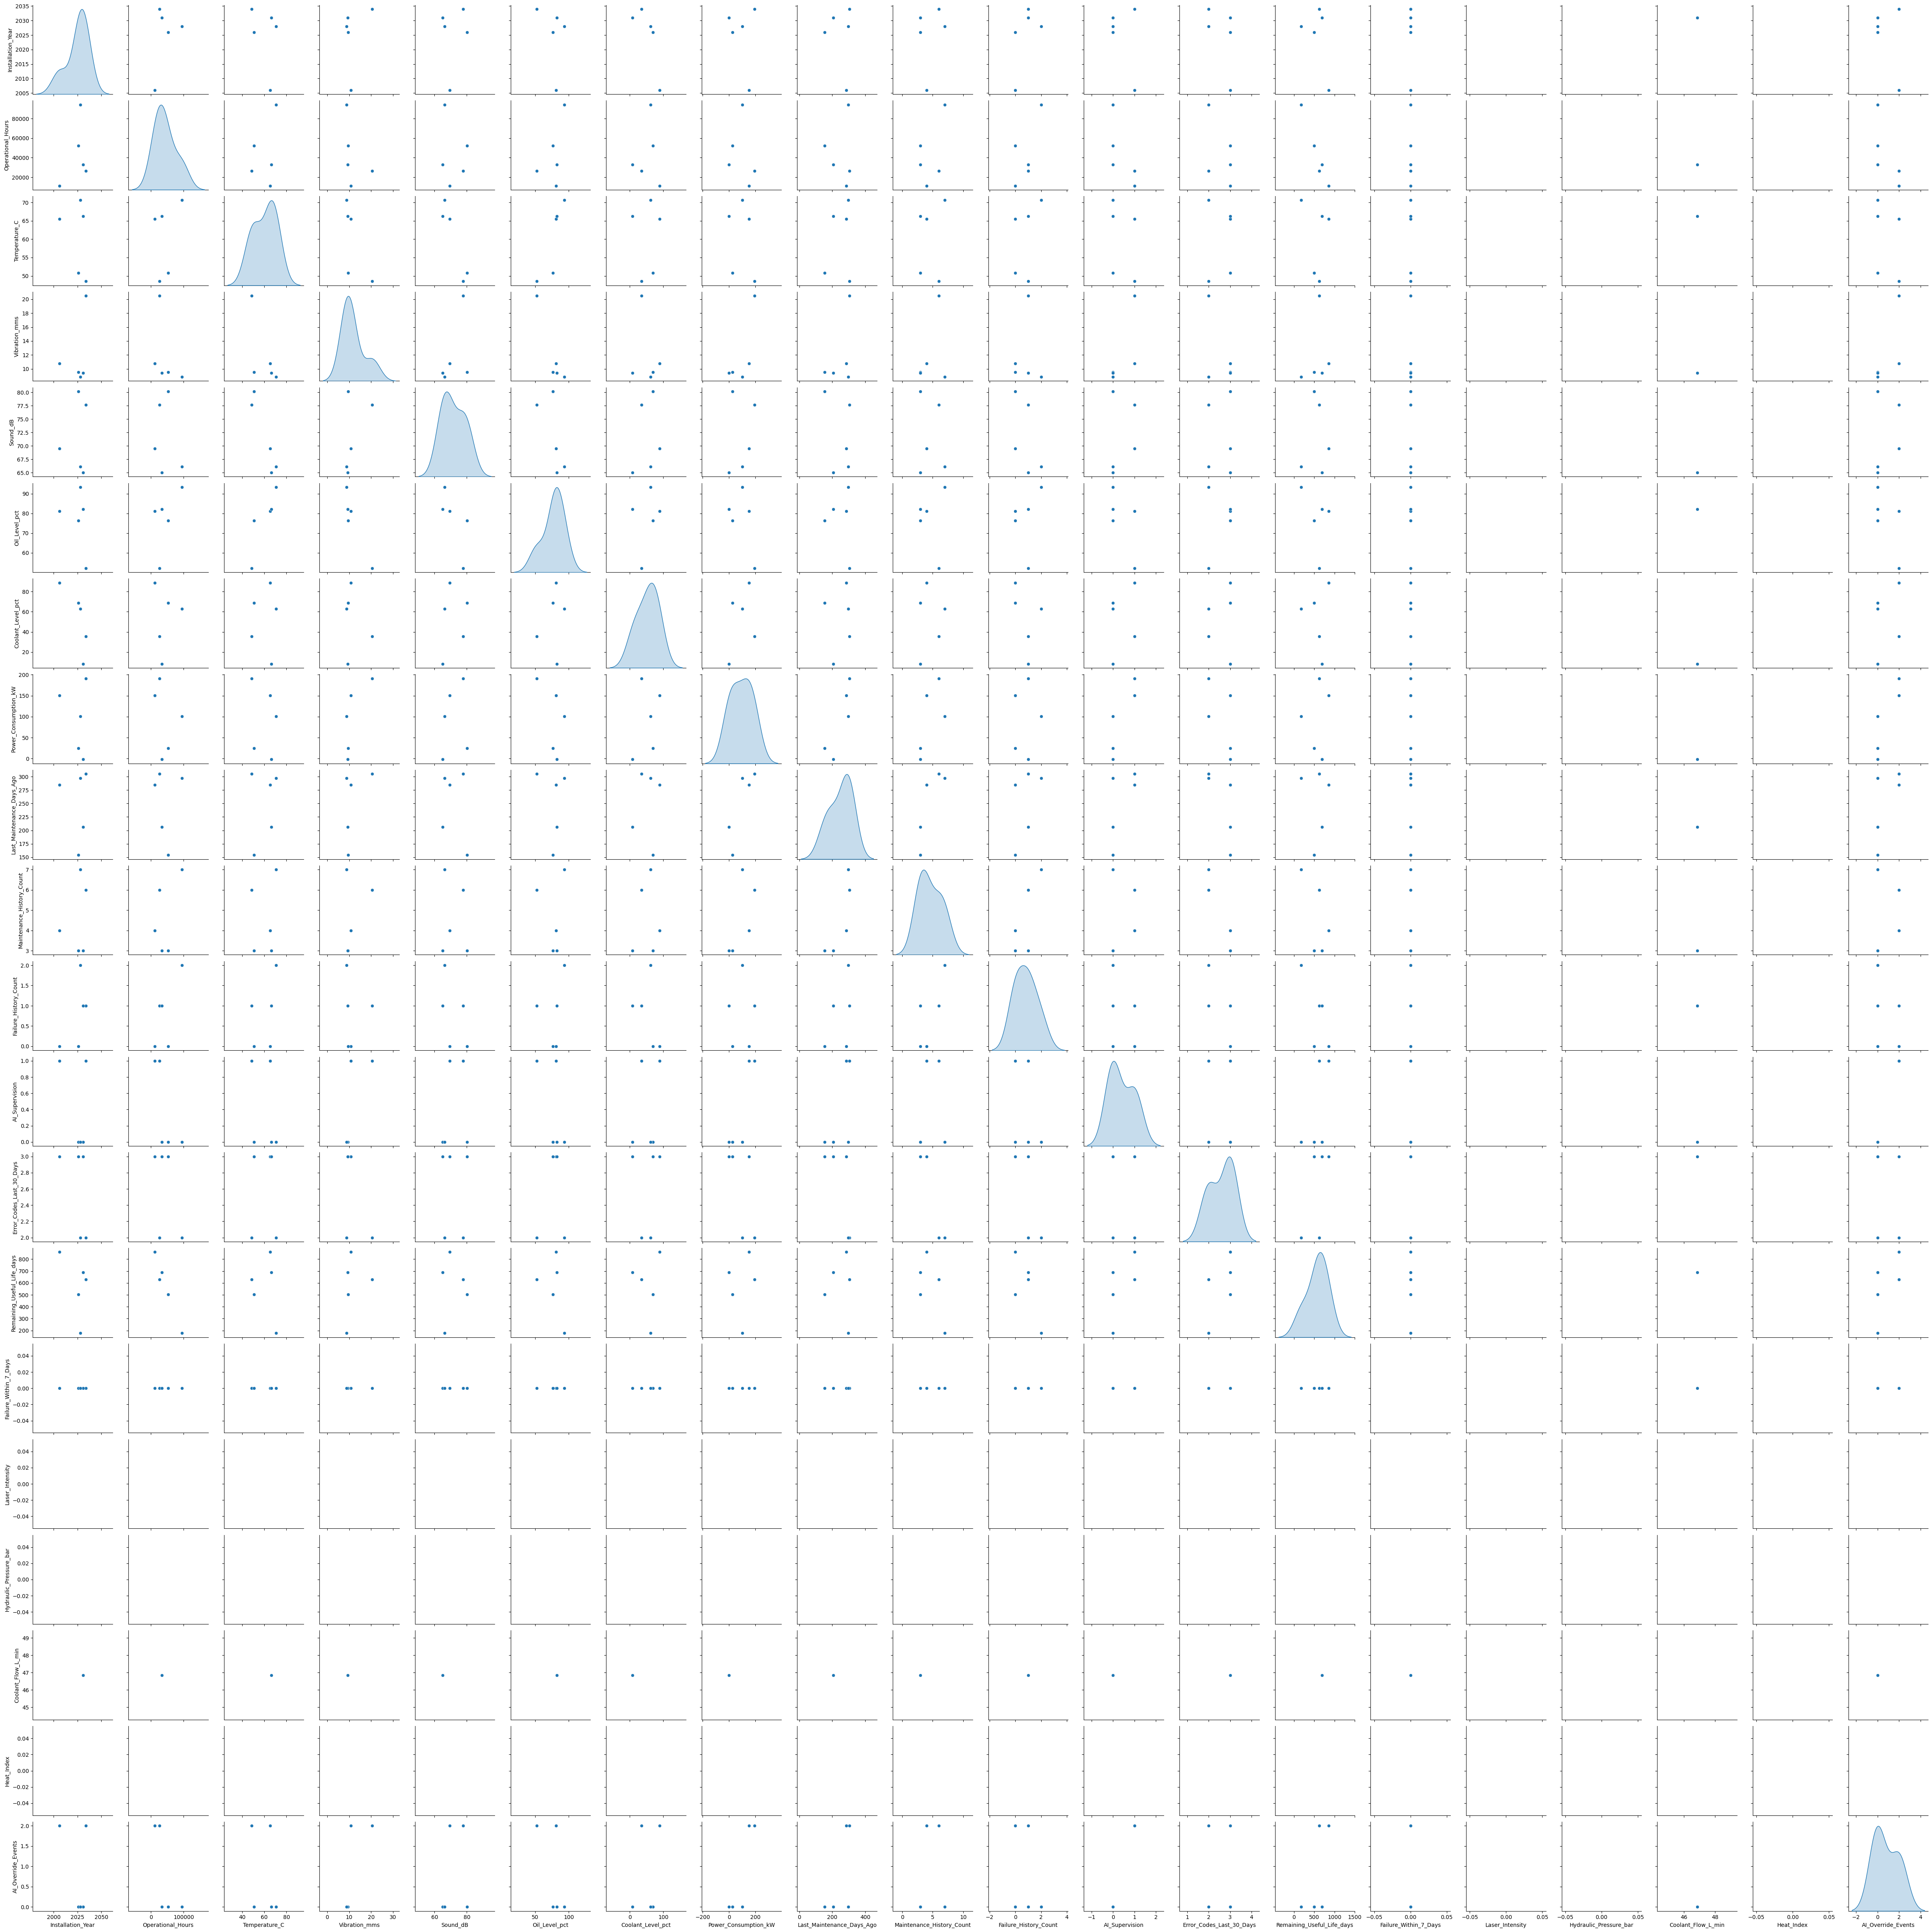

In [7]:
sns.pairplot(df.sample(5), diag_kind='kde')
plt.show()

In [9]:
df = df.drop(columns=['Laser_Intensity','Hydraulic_Pressure_bar','Coolant_Flow_L_min','Heat_Index'])

KeyError: "['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index'] not found in axis"

In [10]:
print(df.columns.tolist())

['Machine_ID', 'Machine_Type', 'Installation_Year', 'Operational_Hours', 'Temperature_C', 'Vibration_mms', 'Sound_dB', 'Oil_Level_pct', 'Coolant_Level_pct', 'Power_Consumption_kW', 'Last_Maintenance_Days_Ago', 'Maintenance_History_Count', 'Failure_History_Count', 'AI_Supervision', 'Error_Codes_Last_30_Days', 'Remaining_Useful_Life_days', 'Failure_Within_7_Days', 'AI_Override_Events']


step4 : preprocessing

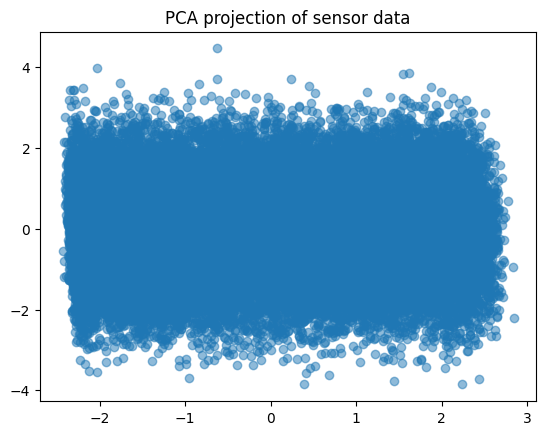

In [11]:
# Drop non-numeric columns if any
num_df = df.select_dtypes(include=[np.number])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.title('PCA projection of sensor data')
plt.show()

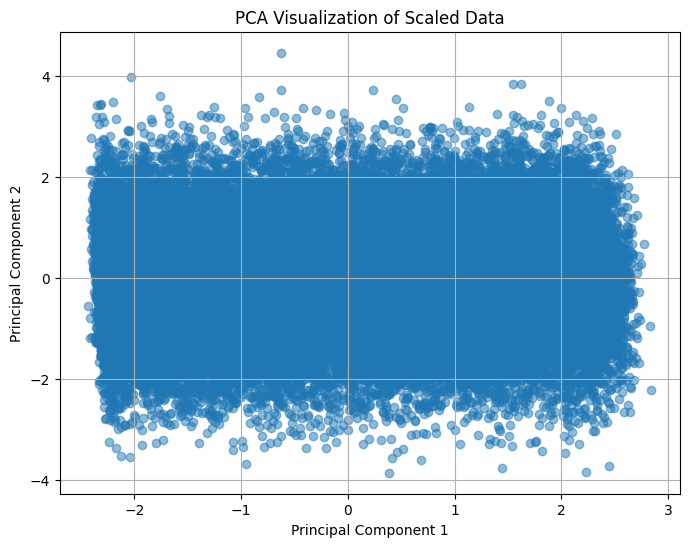

Explained variance ratio: [0.14187479 0.07332695]
Explained variance ratio: [0.14187479 0.21520175]


In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Perform PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Scatter plot of the PCA-transformed data
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Scaled Data')
plt.grid(True)
plt.show()
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Explained variance ratio:",pca.explained_variance_ratio_.cumsum())

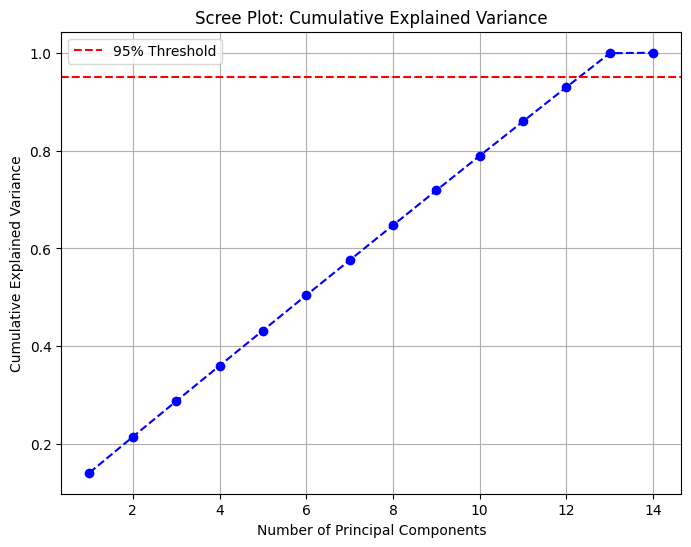

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Fit PCA on your scaled data
pca = PCA()
pca.fit(X_scaled)

# Plot the scree plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(),
         marker='o', linestyle='--', color='b')
plt.title('Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.legend()
plt.show()

step5 :LOP

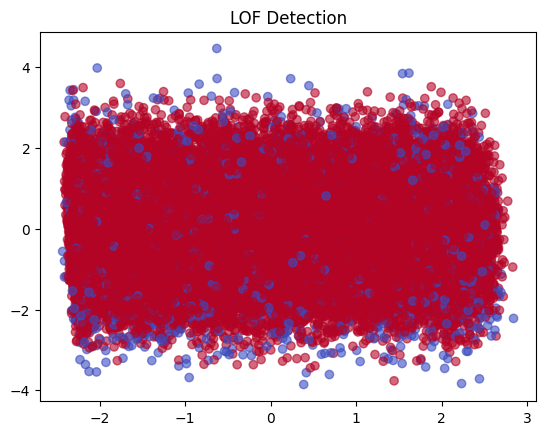

In [18]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred_lof = lof.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred_lof, cmap='coolwarm', alpha=0.6)
plt.title('LOF Detection')
plt.show()

step6  Isolation Forest

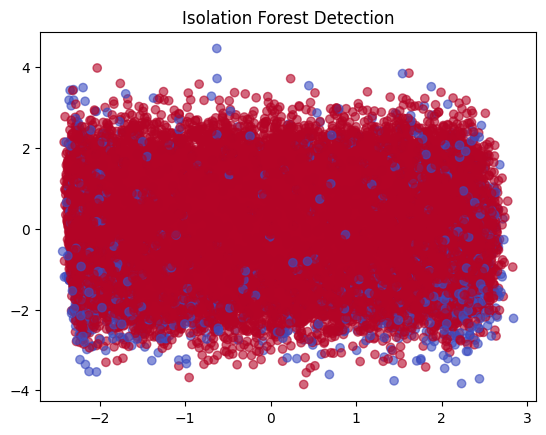

In [14]:
iso = IsolationForest(contamination=0.05, random_state=42)
y_pred_iso = iso.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred_iso, cmap='coolwarm', alpha=0.6)
plt.title('Isolation Forest Detection')
plt.show()

step7 One-Class SVM

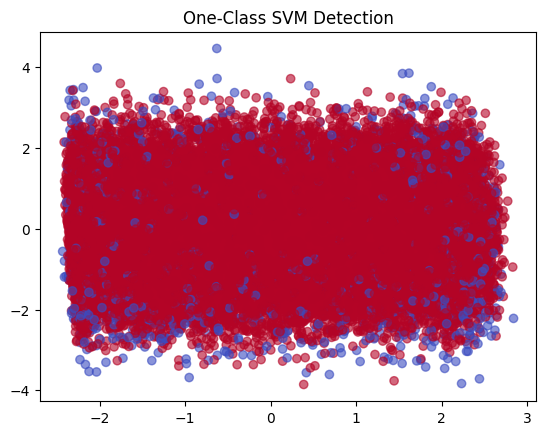

In [15]:
ocsvm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
y_pred_ocsvm = ocsvm.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred_ocsvm, cmap='coolwarm', alpha=0.6)
plt.title('One-Class SVM Detection')
plt.show()

step8 DBSCAN

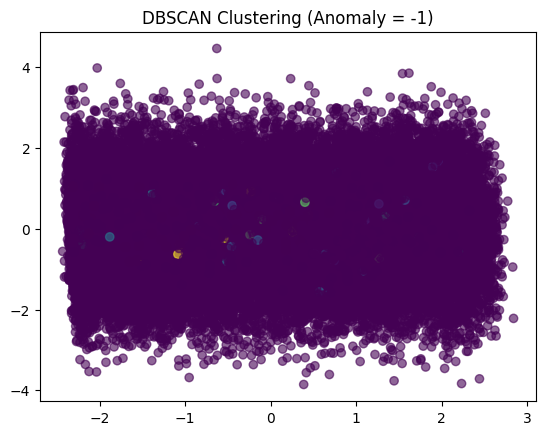

In [16]:
db = DBSCAN(eps=1.5, min_samples=10)
y_pred_db = db.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred_db, cmap='viridis', alpha=0.6)
plt.title('DBSCAN Clustering (Anomaly = -1)')
plt.show()

final : compare models

In [19]:

results = {
    'LOF_outliers': (y_pred_lof==-1).sum(),
    'IF_outliers': (y_pred_iso==-1).sum(),
    'OCSVM_outliers': (y_pred_ocsvm==-1).sum(),
    'DBSCAN_noise': (y_pred_db==-1).sum()
}

print('Anomaly counts by method:')
print(results)

Anomaly counts by method:
{'LOF_outliers': np.int64(2500), 'IF_outliers': np.int64(2500), 'OCSVM_outliers': np.int64(2509), 'DBSCAN_noise': np.int64(49631)}


# **Results**


Three models (LOF, Isolation Forest, and One-Class SVM) consistently identified around 5% of the data as anomalies, indicating stable and reliable detection of abnormal machine behavior. However, DBSCAN classified nearly all data points as anomalies, which suggests poor parameter tuning rather than actual data issues. Therefore, Isolation Forest and LOF are more reliable for this dataset.


Isolation Forest because it is scalable, consistent with other models, and performs well on high-dimensional data.

LOF, Isolation Forest, One-Class SVM detected ~5% anomalies (~2500 points)
DBSCAN classified almost all data (~99%) as anomalies, which is incorrect